class,bad,good
personal_status,,
female div/dep/mar,109,201
male div/sep,20,30
male mar/wid,25,67
male single,146,402


class,bad,good
saving_status,,
100<=X<500,34,69
500<=X<1000,11,52
<100,217,386
>=1000,6,42
no known savings,32,151


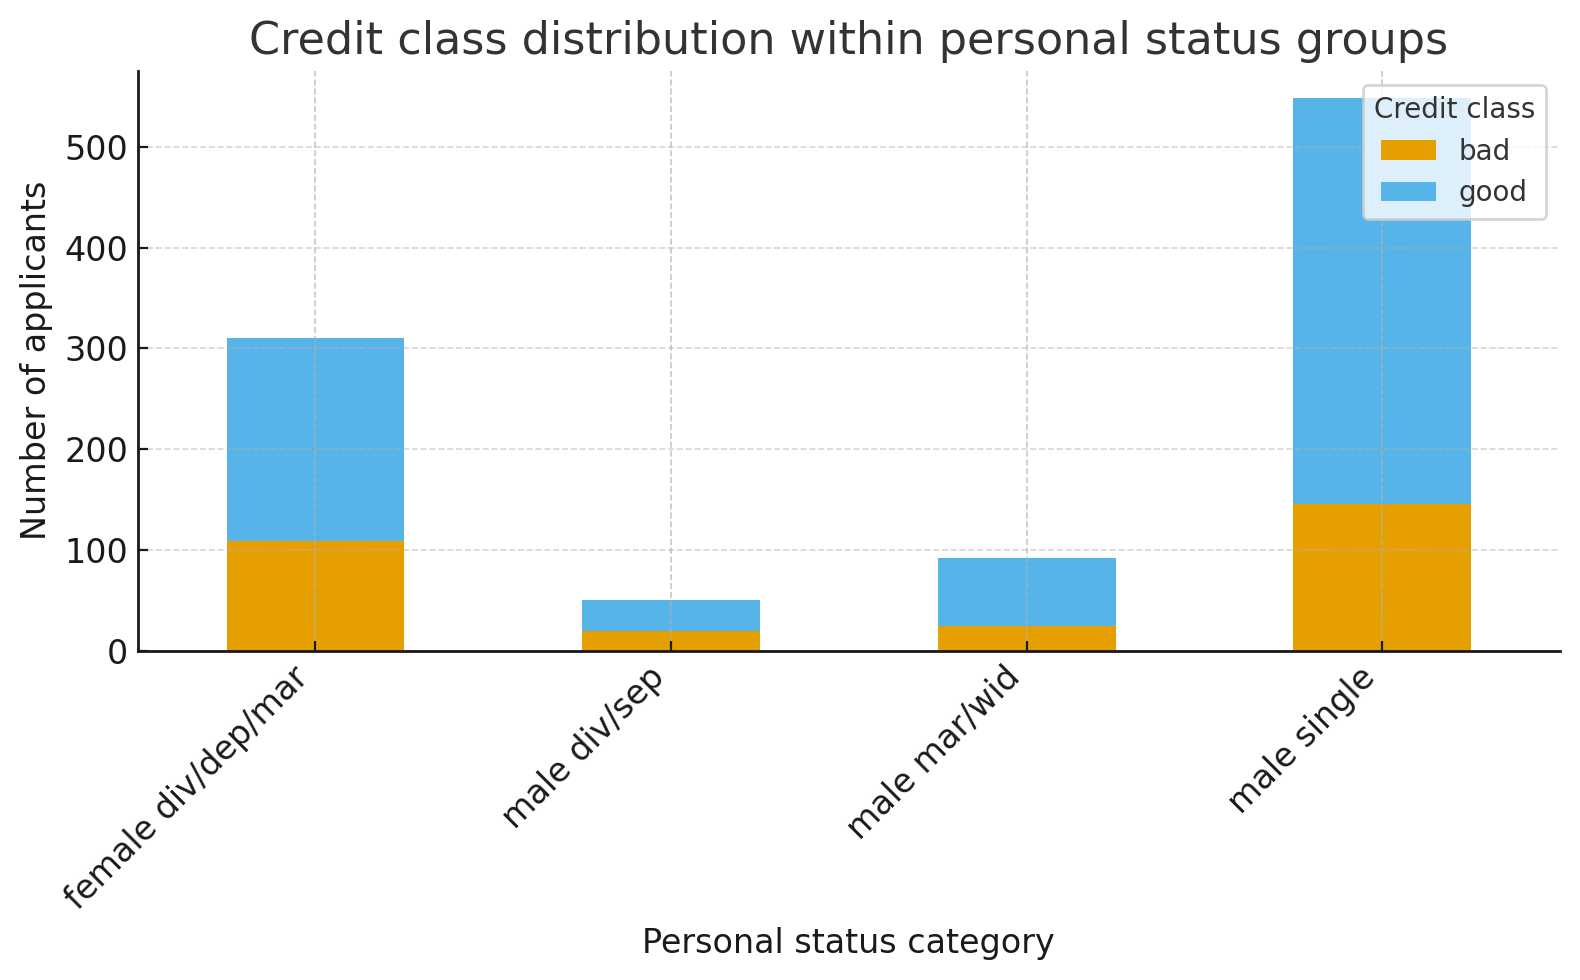

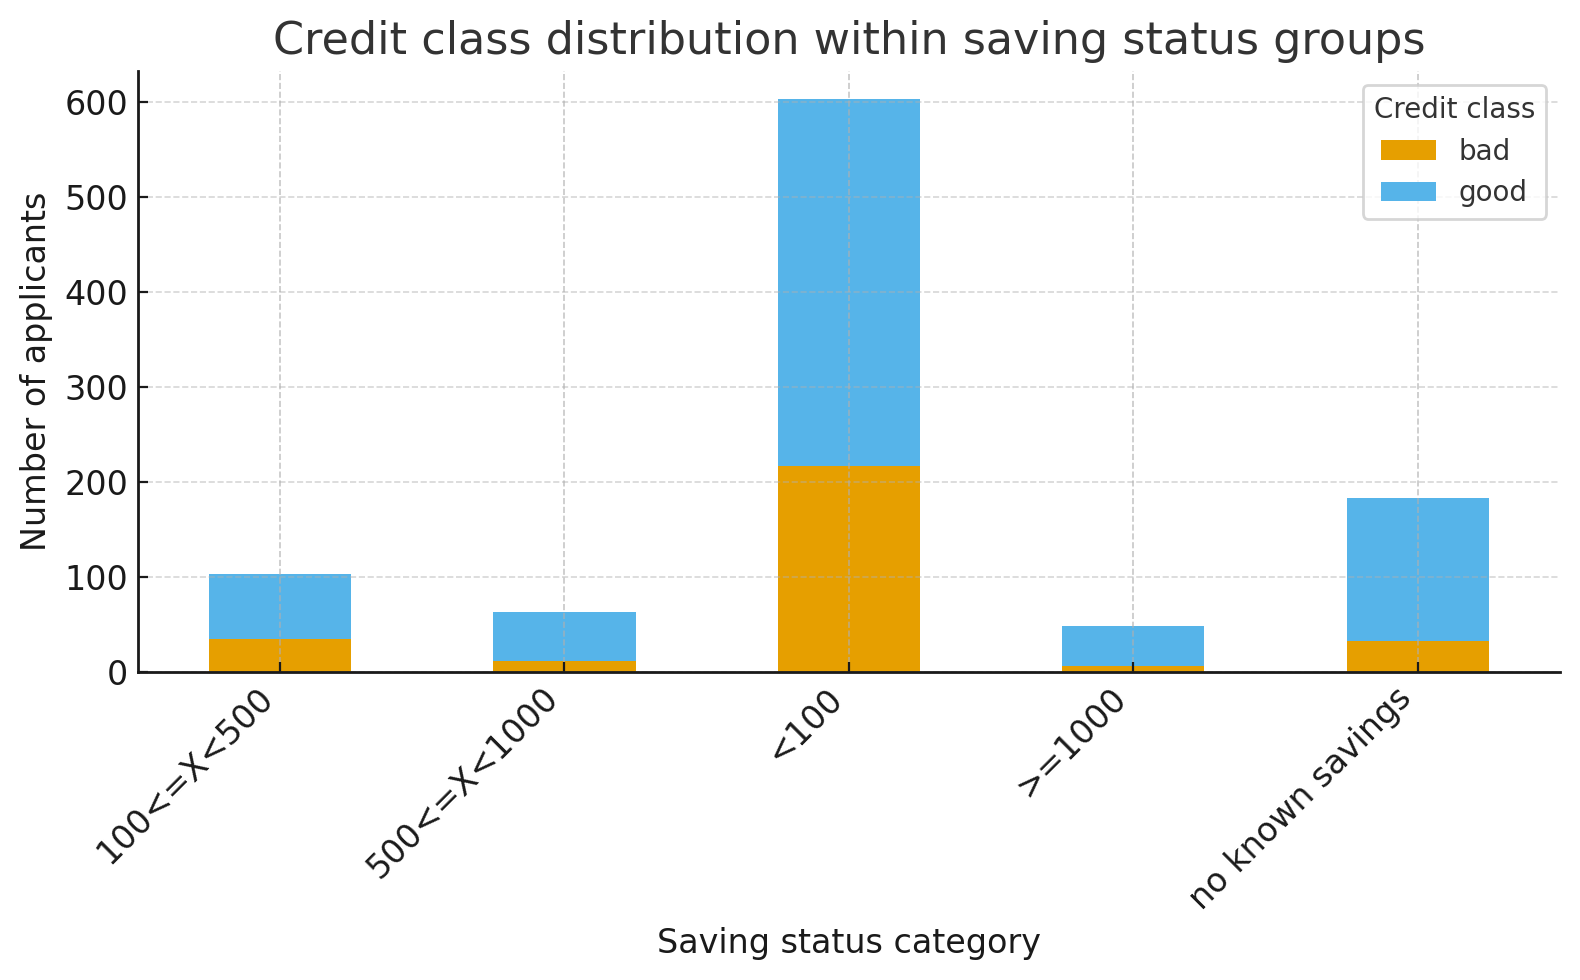

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# I keep the file name in a variable so that it is easy to reuse or change later.
DATA_FILE = "SET09120_CW1_40735842_CLEANING.csv"

def load_credit_dataframe(path: str) -> pd.DataFrame:
    """
    Read the cleaned credit file and standardise column names so that they are
    convenient to use in Python code (lower case, no spaces).
    """
    raw = pd.read_csv(path)
    renamed = (
        raw
        .rename(columns=lambda c: c.strip())
        .rename(columns=lambda c: c.lower())
    )
    renamed.columns = renamed.columns.str.replace(" ", "_")
    return renamed

# Load the dataset and create contingency tables for the two predictors.
credit_df = load_credit_dataframe(DATA_FILE)

personal_ct = pd.crosstab(
    credit_df["personal_status"],
    credit_df["class"],
    dropna=False
)

saving_ct = pd.crosstab(
    credit_df["saving_status"],
    credit_df["class"],
    dropna=False
)

display(personal_ct)
display(saving_ct)

def plot_stacked_distribution(table: pd.DataFrame, title: str, x_label: str) -> None:
    """
    Helper function for drawing a stacked bar chart from a contingency table.

    Each row of the table corresponds to a category of the predictor and each
    column is a credit class.
    """
    ax = table.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 5)
    )
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Number of applicants")
    ax.legend(title="Credit class", loc="upper right")

    # Make the x-axis categories readable and add a light reference grid.
    plt.xticks(rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

# Visual summaries for both predictors.
plot_stacked_distribution(
    personal_ct,
    "Credit class distribution within personal status groups",
    "Personal status category"
)

plot_stacked_distribution(
    saving_ct,
    "Credit class distribution within saving status groups",
    "Saving status category"
)


In [2]:
from scipy.stats import chi2_contingency

# I use the same contingency tables constructed in the previous cell.
alpha = 0.05  # 5% significance level

chi2_personal, p_personal, dof_personal, expected_personal = chi2_contingency(personal_ct)
chi2_saving, p_saving, dof_saving, expected_saving = chi2_contingency(saving_ct)

print("Chi-square test for personal_status vs credit class")
print(f"  test statistic : {chi2_personal:.3f}")
print(f"  degrees of freedom : {dof_personal}")
print(f"  p-value : {p_personal:.4f}")

print("\nChi-square test for saving_status vs credit class")
print(f"  test statistic : {chi2_saving:.3f}")
print(f"  degrees of freedom : {dof_saving}")
print(f"  p-value : {p_saving:.4f}")

def interpret_result(p_value: float, feature_name: str, alpha: float = 0.05) -> str:
    """Return a short textual interpretation of a chi-square p-value."""
    if p_value < alpha:
        return (
            f"For {feature_name}, p = {p_value:.4f} < {alpha}. "
            "I therefore reject the null hypothesis that it is independent of credit class "
            "and treat this feature as being associated with the credit outcome in this sample."
        )
    else:
        return (
            f"For {feature_name}, p = {p_value:.4f} ≥ {alpha}. "
            "I do not have enough evidence to say that this feature is associated with the credit class."
        )

print("\nInterpretation at the 5% significance level")
print(interpret_result(p_personal, "personal status"))
print(interpret_result(p_saving, "saving status"))


Chi-square test for personal_status vs credit class
  test statistic : 9.605
  degrees of freedom : 3
  p-value : 0.0222

Chi-square test for saving_status vs credit class
  test statistic : 36.099
  degrees of freedom : 4
  p-value : 0.0000

Interpretation at the 5% significance level
For personal status, p = 0.0222 < 0.05. I therefore reject the null hypothesis that it is independent of credit class and treat this feature as being associated with the credit outcome in this sample.
For saving status, p = 0.0000 < 0.05. I therefore reject the null hypothesis that it is independent of credit class and treat this feature as being associated with the credit outcome in this sample.
